In [2]:
import mysql.connector
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime

In [3]:
query = "SELECT timestamp, download_speed, upload_speed FROM speed_tests"
cursor.execute(query)


NameError: name 'cursor' is not defined

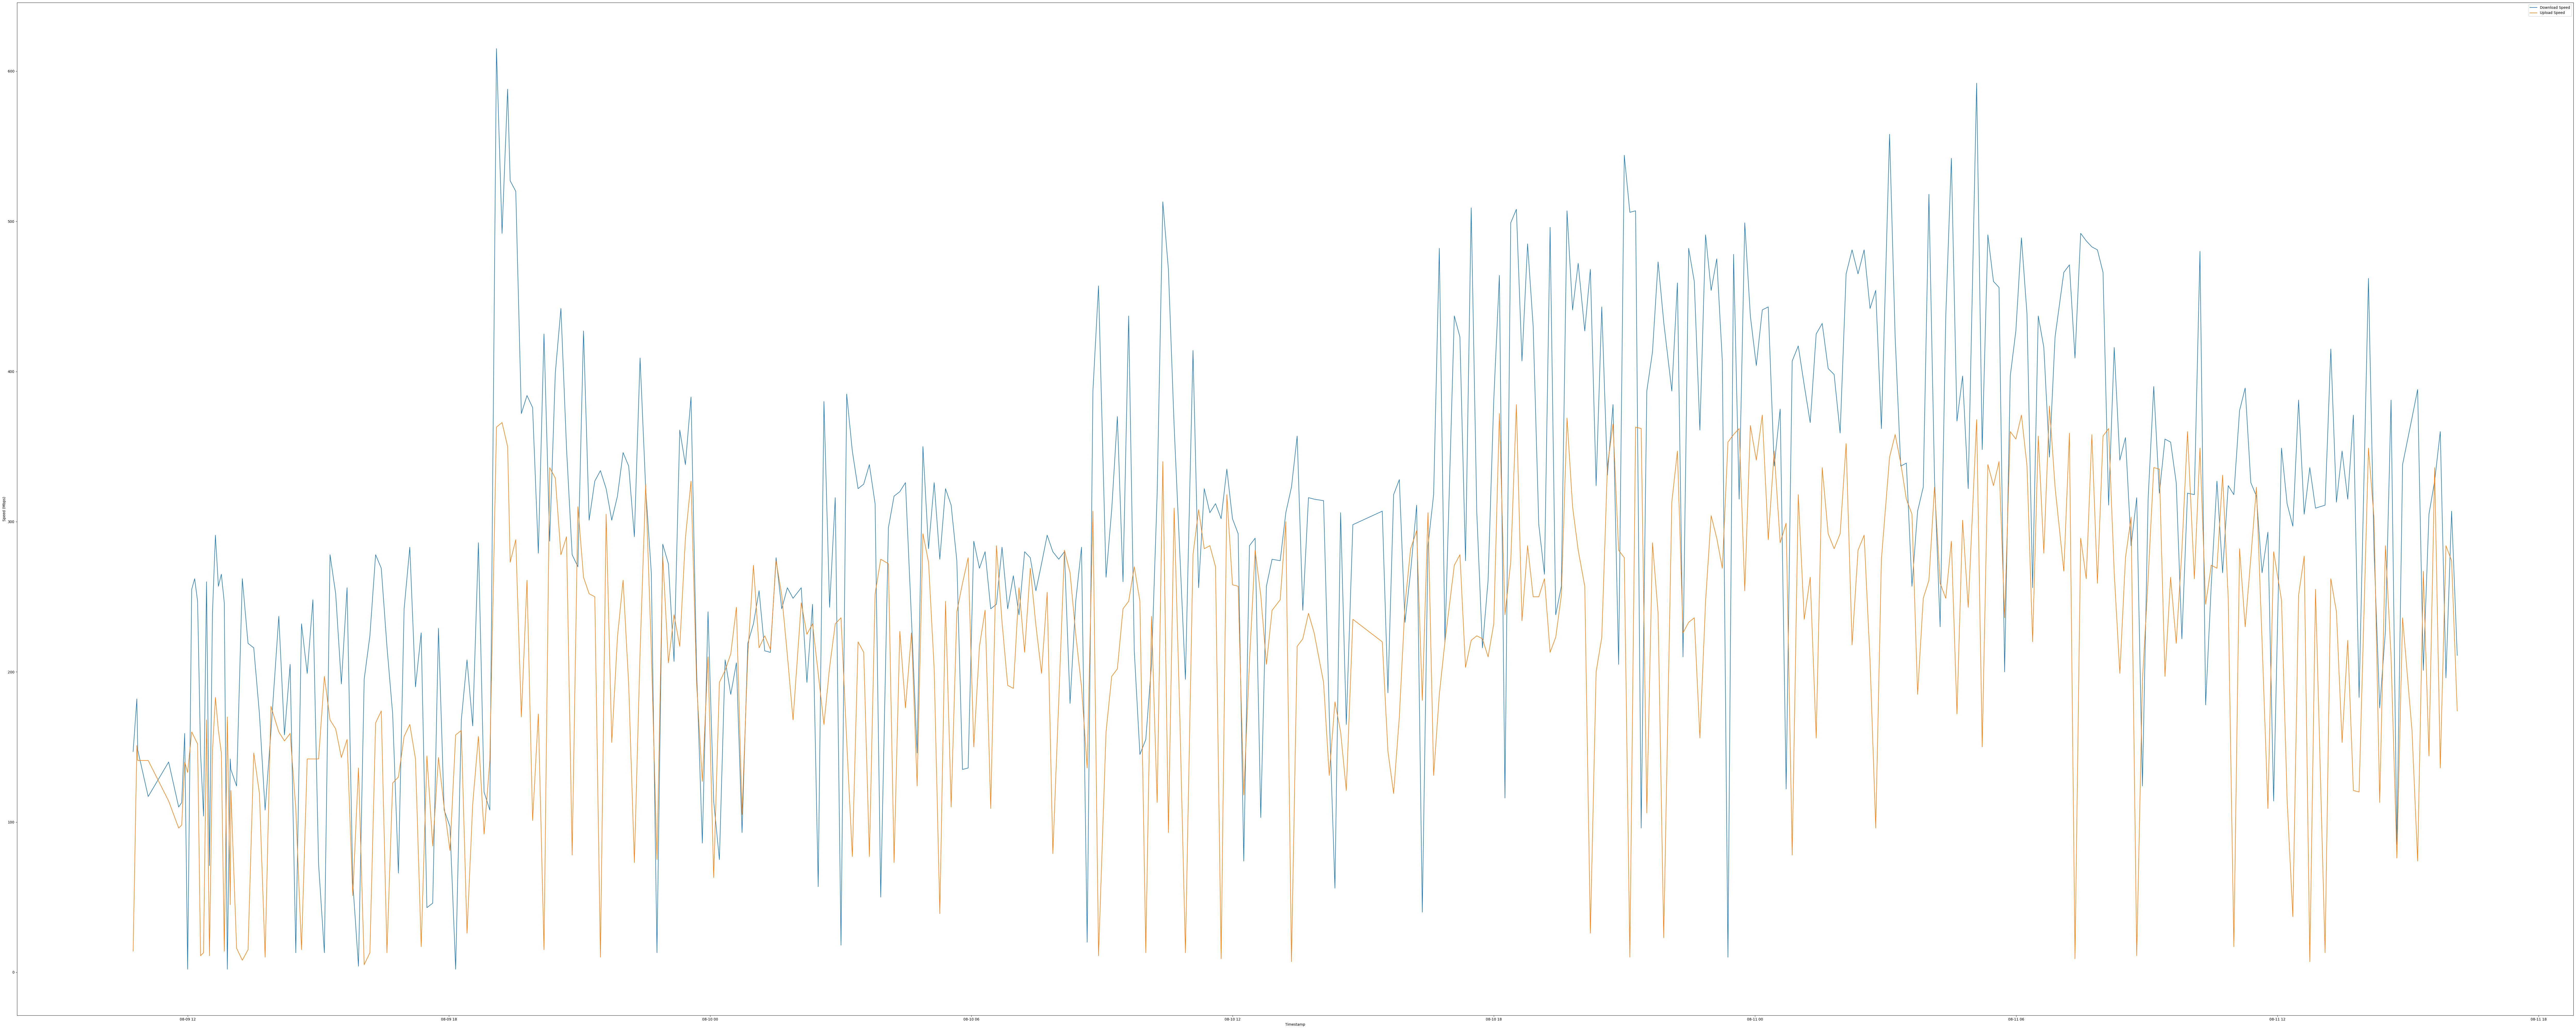

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

KeyboardInterrupt: 

In [20]:
timestamps = []
download_speeds = []
upload_speeds = []

# Create the figure and axes for plotting
fig, ax = plt.subplots(figsize=(100, 40))

# Main loop to continuously query and plot
while True:
    cnx = mysql.connector.connect(
        user='root',
        password='root',
        host='localhost',  # 'localhost',
        port=3314,
        database='db_internet_monitoring',
    )
    cursor = cnx.cursor(dictionary=True,)
    query = "SELECT timestamp, download_speed, upload_speed FROM speed_tests ORDER BY timestamp ASC;"
    cursor.execute(query)

    # Clear existing data and fetch new data from the database
    timestamps.clear()
    download_speeds.clear()
    upload_speeds.clear()
    for row in cursor:
        timestamps.append(row['timestamp'])
        download_speeds.append(row['download_speed'])
        upload_speeds.append(row['upload_speed'])

    # Clear the plot axes and redraw the lines with the updated data
    ax.clear()
    ax.plot(timestamps, download_speeds, label='Download Speed')
    ax.plot(timestamps, upload_speeds, label='Upload Speed')
    ax.legend()  # Add the legend to the plot
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Speed (Mbps)')
    plt.tight_layout()

    # Pause for a short duration before the next update
    plt.pause(5)

    cursor.close()
    cnx.close()

In [33]:
!pip install plotly
!pip install pandas


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip
  Using cached pytz-2024.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2024.1-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 34.4 MB/s eta 0:00:00m eta 0:00:010:01:01
Using cached pytz-2024.1-py2.py3-none-any.whl (505 kB)
Using cached tzdata-2024.1-py2.py3-none-any.whl (345 kB)

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [4]:
cnx = mysql.connector.connect(
        user='root',
        password='root',
        host='localhost',  # 'localhost',
        port=3314,
        database='db_internet_monitoring',
    )
cursor = cnx.cursor(dictionary=True,)

In [1]:
import plotly.graph_objects as go
import pandas as pd
import time



# Main loop to continuously query and plot
once = True
while True:
    fig = go.Figure()
    
    query = "SELECT * FROM speed_tests ORDER BY timestamp ASC"  # Fetch all columns
    cursor.execute(query)

    # Fetch data into a Pandas DataFrame for easier handling
    df = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in cursor.description])
    df = df.sort_values('timestamp')
    df["spected"] = 700
    df["mean"] = df["download_speed"].mean()
    # Create custom hover text template
    hover_template = "<b>Timestamp:</b> %{x}<br>"
    for col in df.columns:
        if col:
            hover_template += f"<b>{col}:</b> %{{customdata[{df.columns.get_loc(col)}]}}<br>"

    print(hover_template)

    # Add traces to the figure with custom hover template
    fig.add_trace(go.Scatter(
        x=df['timestamp'], 
        y=df['download_speed'], 
        mode='lines', 
        name='Download Speed',
        customdata=df.values,  # Pass all data for hover
        hovertemplate=hover_template
    ))
    fig.add_trace(go.Scatter(
        x=df['timestamp'], 
        y=df['upload_speed'], 
        mode='lines', 
        name='Upload Speed',
        customdata=df.values,  # Pass all data for hover
        hovertemplate=hover_template
    ))
    fig.add_trace(go.Scatter(
        x=df['timestamp'], 
        y=df['mean'], 
        mode='lines', 
        name='Mensal Mean',
        customdata=df.values,  # Pass all data for hover
        hovertemplate=hover_template
    ))
    fig.add_trace(go.Scatter(
        x=df['timestamp'], 
        y=df['spected'], 
        mode='lines', 
        name='Spected',
        customdata=df.values,  # Pass all data for hover
        hovertemplate=hover_template
    ))

    # Update layout for better visualization
    fig.update_layout(
        title='Internet Speed Monitoring',
        xaxis_title='Timestamp',
        yaxis_title='Speed (Mbps)',
        hovermode='x' 
    )

    # Show the plot (this will open in your web browser)
    # fig.show()

    # Save the plot as an HTML file (optional)
    fig.write_html('internet_speed_plot.html')

    # Pause for a short duration before the next update
    #time.sleep(5)
    once = False

ModuleNotFoundError: No module named 'pandas'